In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from param_estim_it4_alteration import run_mcmc

C:\Users\Træning 3\AppData\Local\Temp\ipykernel_5124\2161736174.py:28: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


These are the B1 vals:  [-0.00000000e+00  1.56388229e-05  1.56388229e-05 ...  1.56388229e-05
  1.56388229e-05  1.56388229e-05] This is the length:  100000
-0.0
42.71239207476682
82.23046410219031
118.79139868264593
152.61647842002068
183.9104273403352
212.86264997013402
239.64837769468764
264.4297293340657
287.35669235669064


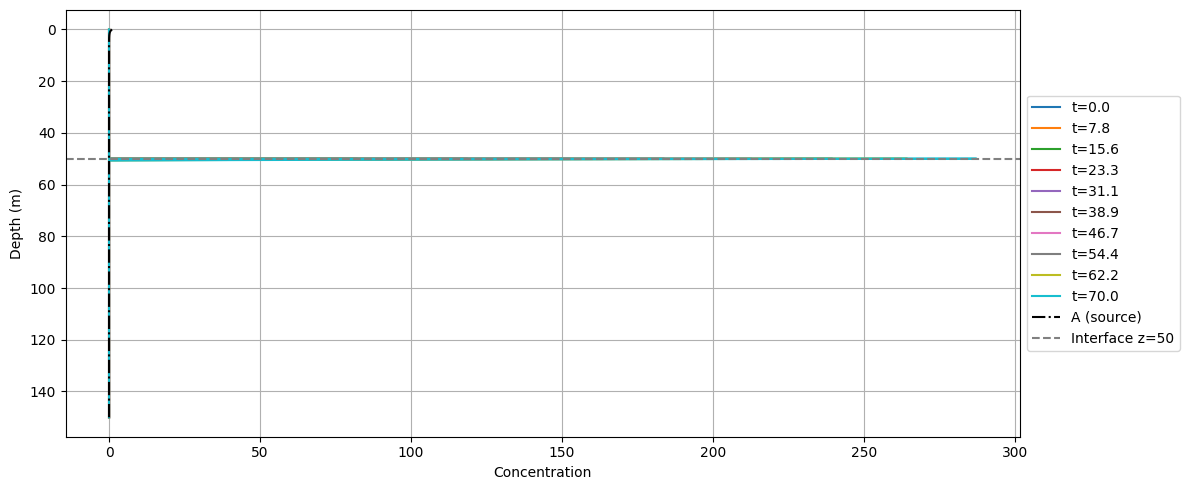

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#alpha = 9.156
#Da    = 1.13
#lambda_ = np.sqrt(alpha / Da)
#kappa   = 0.023
#u1      = 82665.16
#u2      = 0.0059

alpha = np.mean([1.74, 1.30, 0.87]) 
Da = 1
lambda_ = np.sqrt(alpha/Da)
kappa = 1.42*10**(-2)
u1= 3.65*10**5
u2= 0.01
C = 60.0

t       = np.linspace(0, 70, 100_000)
z1      = np.linspace(0,  50, 50_000)
z2_phys = np.linspace(50, 150, 100_000)


# ── B1 ──────────────────────────────────────────────────────────────────────
def B_func51(z, t_val, u1, alpha, lambda_, kappa, C):
    a  = kappa - lambda_ * u1
    b_ss  = (alpha / a) * C * np.exp(-lambda_ * z) * (1 - np.exp(-a * z / u1))
    b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))
    return np.where(z <= u1 * t_val, b_ss, b_tr)


# ── B1 evaluated exactly at z = 50 ──────────────────────────────────────────
def B1_at_50(t_array, u1, alpha, lambda_, kappa, C):
    """Simply evaluate B_func51 at z=50 for each t — no clamp."""
    return B_func51(50.0, t_array, u1, alpha, lambda_, kappa, C)


# ── Interface ODE — convolution integral ─────────────────────────────────────
def interface_M(t_array, u1, u2, alpha, lambda_, kappa, C):
    """
    M(t) = ∫₀ᵗ  u1 · B1(50, τ) · exp(−u2·(t−τ))  dτ

    Computed incrementally so we only do O(N) work instead of O(N²).
    Update rule (trapezoidal, step by step):
        M(t_{n+1}) = M(t_n)·exp(−u2·Δt)
                   + Δt·u1·½·[B1(50,t_n)·exp(−u2·Δt) + B1(50,t_{n+1})]
    This is the exact integral assuming B1 is linear between steps.
    """
    t_array = np.asarray(t_array)
    M       = np.zeros_like(t_array)
    B1_vals = B1_at_50(t_array, u1, alpha, lambda_, kappa, C)
    print("These are the B1 vals: ", B1_vals, "This is the length: ", len(B1_vals))

    for i in range(1, len(t_array)):
        dt_i   = t_array[i] - t_array[i - 1]
        decay  = np.exp(-u2 * dt_i)
        # trapezoidal on the integrand f(τ) = u1·B1(50,τ) between t_{i-1} and t_i
        f_prev = u1 * B1_vals[i - 1]
        f_curr = u1 * B1_vals[i]
        M[i]   = M[i - 1] * decay + dt_i * 0.5 * (f_prev * decay + f_curr)

    return M


# ── B2 ──────────────────────────────────────────────────────────────────────
def B_func52(z2_phys, t_val, u2, alpha, lambda_, t_array, kappa, M_vals, C):
    a2 = kappa - lambda_ * u2
    z2 = z2_phys - 50.0        # shifted coordinate (0 at interface)

    # Characteristic travel time from interface to z
    tau_travel = z2 / u2

    # Retarded time (clipped to [0, t_val] and to array bounds)
    tau = np.clip(t_val - tau_travel, 0.0, t_array[-1])

    # M interpolated at the retarded time
    M_tau = np.interp(tau, t_array, M_vals)

    # Branch 1: characteristic has arrived (z2 ≤ u2·t_val)
    b1 = ( (alpha / a2) * C * np.exp(-lambda_ * z2_phys)
           + (M_tau - (alpha / a2) * C * np.exp(-lambda_ * 50.0))
             * np.exp(-kappa * tau_travel) )

    # Branch 2: characteristic has not yet arrived
    b2 = (alpha / a2) * C * np.exp(-lambda_ * z2_phys) * (1.0 - np.exp(-a2 * t_val))

    return np.where(z2 <= u2 * t_val, b1, b2)


# ── Compute M once ───────────────────────────────────────────────────────────
M_vals = interface_M(t, u1, u2, alpha, lambda_, kappa, C)

# ── Plot ─────────────────────────────────────────────────────────────────────
z_full = np.concatenate([z1, z2_phys])
A_full = np.exp(-lambda_ * z_full)

indices   = np.linspace(0, len(t) - 1, 10, dtype=int)
t_sampled = t[indices]

plt.figure(figsize=(12, 5))
for ti in t_sampled:
    B1 = B_func51(z1, ti, u1, alpha, lambda_, kappa, C)
    B2 = B_func52(z2_phys, ti, u2, alpha, lambda_, t, kappa, M_vals, C)
    B  = np.concatenate([B1, B2])
    print(max(B))
    plt.plot(B, z_full, label=f"t={ti:.1f}")

plt.plot(A_full, z_full, 'k-.', label="A (source)")
plt.axhline(50, linestyle='--', color='grey', label="Interface z=50")
plt.gca().invert_yaxis()
plt.xlabel("Concentration")
plt.ylabel("Depth (m)")
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [3]:
print("Alpha", alpha, "Da", Da, "kappa", kappa, "U1", u1, "U2", u2, "C", C)

Alpha 1.3033333333333335 Da 1 kappa 0.014199999999999999 U1 365000.0 U2 0.01 C 5.0


5.0
5.0
5.0
36.76310835357045
68.50925586690884
97.88098070219145
125.05587752623943
150.19825675710143
173.4601481612306
194.9821738428031


c:\Users\Træning 3\OneDrive - Roskilde Universitet\12. semester\Speciale - General\Numerik\Scripts\MCMC\it4\it4_anal_solver.py:16: RuntimeWarning: overflow encountered in exp
  b_tr  = (alpha / a) * np.exp(-lambda_ * z) * (1 - np.exp(-a * t_val))


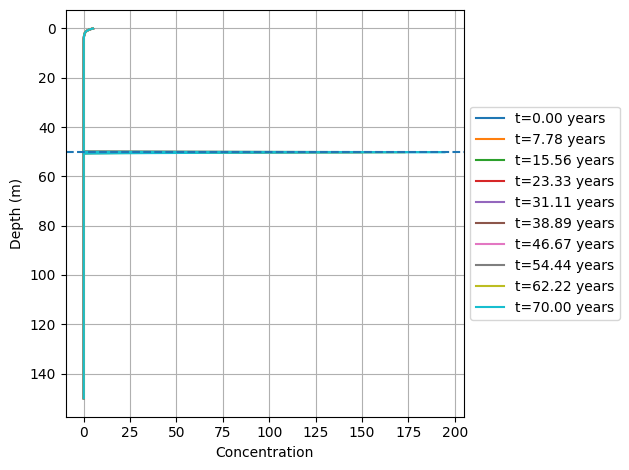

In [4]:
# plot
from it4_anal_solver import B_funky
C = 5
zeta = np.linspace(0, 150, 1000)
for i in range(len(t_sampled)):
    ti = t_sampled[i]
    t = np.linspace(0, ti, 1000)  # NEW time array up to current ti
    full = B_funky(zeta, ti, u1, u2, alpha, Da, kappa, C, t)
    plt.plot(full, zeta, label=f"t={ti:.2f} years")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    print(max(full))

    #print(f"Max error at t={ti:.2f} years: {np.max(error)}")
plt.ylabel("Depth (m)")
plt.xlabel("Concentration")
plt.axhline(y=50, linestyle='--',label="Seabed")
plt.gca().invert_yaxis()
plt.grid()

plt.tight_layout()
#plt.ylim(5,0)

plt.show()


In [5]:

L = 150.0

water_raw = [
    (2.5,   3.5667891682785307),
    (7.5,   2.6969926716060204),
    (12.5,  0.9080153525061379),
    (17.5,  0.5380893150797977),
    (27.5,  0.15000000000000002),
    (32.5,  0.17777777777777778),
    (42.5,  0.07500000000000001),
    (47.5,  0.1),
]
sediment_raw = [   # (bin_centre_cm, concentration)
    (0.0125,               634.7414656833154),
    (0.037500000000000006, 478.3568408220815),
    (0.0625,               970.1680149695655),
    (0.08750000000000001,  2343.5408338909124),
    (0.1125,               1420.2905042168202),
    (0.1375,               1237.2282190132125),
    (0.16250000000000003,  1026.581643277907),
    (0.1875,               299.62609220263096),
    (0.21250000000000002,  681.4776292062617),
    (0.2375,               458.20696863375105),
    (0.2625,               422.2530388157952),
    (0.3125,               640.1515738798312),
    (0.3875,               63.55031042845192),
    (0.41250000000000003,  187.55853823063677),
    (0.48750000000000004,  30.846954308574094),
    (0.5375000000000001,   30.516169700062356),
    (0.6125,               17.81769496827207),
]

water_z   = np.array([r[0]                for r in water_raw])
water_val = np.array([r[1]                for r in water_raw])
sed_z     = np.array([r[0] + 50.0 for r in sediment_raw])  # cm→m + offset
sed_val   = np.array([r[1]                for r in sediment_raw])

# Zero-padding: penalise mass past the last observed depth
pad_z   = np.arange(sed_z[-1] + 0.5, L + 0.5, 10)
pad_val = np.zeros(len(pad_z))

obs_z   = np.concatenate([water_z, sed_z, pad_z])
obs_val = np.concatenate([water_val, sed_val, pad_val])
# --- fixed solver inputs ---
t_final = 70.0
t_array = np.linspace(0, t_final, 2000)
z_grid  = np.linspace(0, 150, 2000)


In [ ]:
from param_estim_it4_alteration import run_mcmc
import numpy as np

# --- Configuration ---
n_chains        = 2
n_iter_per_chain = 5_000_000
params_to_check = ['Da', 'kappa']
C = 5.0
init_p = {
    'z_grid':  z_grid,
    't':       t_final,
    'Da':      Da,
    'u1':      u1,
    'u2':      u2,
    'C':      60,
    't_array': t_array,
    'alpha':   alpha,
    
}

# Define dispersed starting points for each chain
# These should span the plausible parameter space
starting_points = [
    {
        'Da'   : np.random.uniform(1.0,   120.0),
        'kappa': np.random.uniform(0.001,  0.20)
        #'C'    : np.random.uniform(1.0,   100.0)
    }
    for _ in range(n_chains)
]

# --- Run chains ---
all_chains = []
all_names  = []

other_weights = np.concatenate([
    water_val / np.max(water_val),
    sed_val   / np.max(sed_val),
    np.ones_like(pad_z)*0.5
])

other_weights = other_weights + 0.5
other_weights = other_weights/np.max(other_weights)

for i in range(n_chains):
    print(f"\nRunning chain {i+1} of {n_chains}...")
    print("These are the chain characteristics"
        f"Chain {i+1:2d}: "
      f"Da={starting_points[i]['Da']:7.3f},  "
      f"kappa={starting_points[i]['kappa']:.4f}")


    # --- parameters to estimate ---
    param_cfg = {
        #'alpha':   {'init': alpha,              'sigma': 0.1, 'lo': 1e-4,  'hi': 2000.0,  'proposal': 'uniform'},
        #'C':      {'init': starting_points[i]['C'],               'sigma': 0.5, 'lo': 1e-4,  'hi': 20_000,  'proposal': 'uniform'},
        'kappa':   {'init': starting_points[i]['kappa'],         'sigma': 0.05, 'lo': 1e-6,  'hi': 20_000,   'proposal': 'uniform'},
        #'u1':       {'init': u1,   'sigma': 100, 'lo': 100,  'hi': 10**10,   'proposal': 'uniform'},
        #'u2':       {'init': u2,    'sigma': 0.01, 'lo': 1e-6,  'hi': 10.0,   'proposal': 'uniform'},
        'Da':      {'init': starting_points[i]['Da'],            'sigma': 1, 'lo': 1e-6,  'hi': 10_000,   'proposal': 'uniform'}
    }
    
        # Run the chain
    _, output_file = run_mcmc(
        obs_z, obs_val, init_p, param_cfg,
        num_iterations=n_iter_per_chain,
        output_name=f'chain_Da_kappa_C={C}_nummer{i+1}_GoodWeights_5mio_its.h5',
        weights=other_weights
    )


Running chain 1 of 2...
These are the chain characteristicsChain  1: Da= 75.884,  kappa=0.0710
  iter      0  cost=618.7350  accept rate=0.00


KeyboardInterrupt: 